# TQ_VAM：波動率調整截面動能策略

> **策略類型：** Pipeline 因子架構 — 截面動能排名  
> **交易標的：** 台股上市普通股（流動性前 100 大）  
> **調倉頻率：** 月度再平衡  
> **論文來源：** *Learning to Rank Enhancing Momentum Strategies Across Asset Classes*

---

## 📌 策略概述

### 核心 Alpha 來源

傳統動能策略（如 JT 訊號）只比較股票的**原始報酬率**，忽略了不同股票的波動差異。  
本策略移植論文中的**風險調整動能（Vol-Adjusted Momentum）**概念：

$$
\text{VAM}_{i,t} = \frac{r_{i}(t-21, t)}{\sigma_{i,t}}
$$

| 項目 | 說明 |
|:---|:---|
| $r_{i}(t-21, t)$ | 過去 21 個交易日累積報酬率 |
| $\sigma_{i,t}$ | 過去 21 日日報酬率標準差（衡量近期波動） |

對流動性前 100 大股票計算 VAM，每月做多 Top 10（等權重）。

### Behavioral Reason

台股散戶佔比高，傾向追漲波動大的熱門股（representativeness bias），  
波動率標準化後能過濾「假動能」（漲幅大但波動更大），留下**真正相對強勢**的股票。  
台股 1–3 個月動能效果在本土研究中已有實證，21 天視窗剛好在有效區間內。

### 策略特色

- **Pipeline 樣本掃描**：每日自動對流動性前 100 股計算因子，無需手動維護名單
- **波動率標準化**：讓高低波動率股票可以公平排名（論文的核心因子之一）
- **流動性雙重過濾**：ingest 時取歷史曾入 TWN100 的成分股，Pipeline 再依平均成交金額取前 100
- **Long-only**：台灣現貨做空限制多，先驗證多頭 alpha

## 📌 環境設定 & 參數

設定 TEJ API 金鑰、回測區間與策略參數。  
投資宇宙使用 `get_universe` 抓取歷史曾入 TWN100 的成分股作為候選母體。

In [1]:
%matplotlib inline
import os
import pandas as pd
import numpy as np
import tejapi
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from logbook import Logger

# TEJ API
os.environ['TEJAPI_KEY']  = 'Q8Grvs9A8jAkQJpUNe3SzZs6rioRIQ'
os.environ['TEJAPI_BASE'] = 'http://tejapi.tejwin.com'
tejapi.ApiConfig.api_key  = os.getenv('TEJAPI_KEY')
tejapi.ApiConfig.api_base = os.getenv('TEJAPI_BASE')

log = Logger('VAM')

# 字型設定：優先使用 SourceHanSansTC（思源黑體繁體中文），Linux 環境無 Microsoft JhengHei
_font_path = '/app/SourceHanSansTC-Regular.otf'
if os.path.exists(_font_path):
    fm.fontManager.addfont(_font_path)
    _font_name = fm.FontProperties(fname=_font_path).get_name()
    plt.rcParams['font.sans-serif'] = [_font_name, 'DejaVu Sans']
    print(f'字型載入：{_font_name}')
else:
    plt.rcParams['font.sans-serif'] = ['DejaVu Sans']
    print('警告：找不到 SourceHanSansTC-Regular.otf，中文可能無法顯示')
plt.rcParams['axes.unicode_minus'] = False

# -- backtest params --
start_date   = '2019-12-30'
end_date     = '2024-12-31'
capital_base = 1_000_000

# -- strategy params --
MOMENTUM_WINDOW  = 21   # 動量計算視窗（交易日）
LIQUIDITY_WINDOW = 30   # 流動性計算視窗（交易日）
LIQUIDITY_TOP_N  = 100  # 流動性過濾：成交金額前 N 大
TOP_N            = 10   # 每月做多前 N 名

# -- filter thresholds --
SPREAD_THRESHOLD = 1.0   # Filter2: VAM spread < this -> half position
CORR_THRESHOLD   = 0.85  # Filter3: rolling corr > this -> half position
CORR_WINDOW      = 20    # Filter3: rolling window (trading days)

# -- universe: 歷史曾入 TWN100 的成分股 --
from zipline.sources.TEJ_Api_Data import get_universe

pool = get_universe(start_date, end_date, idx_id='IX0003')
print(f'Universe (歷史 TWN100): {len(pool)} stocks')

os.environ['mdate']  = f'{start_date} {end_date}'
os.environ['ticker'] = ' '.join(pool)

print(f'Backtest: {start_date} ~ {end_date}')
print(f'Top {TOP_N} equal-weight = {1/TOP_N:.1%} each')

字型載入：Source Han Sans TC
Currently used TEJ API key call quota 32/100000 (0.03%)
Currently used TEJ API key data quota 1583281/10000000 (15.83%)
Universe (歷史 TWN100): 168 stocks
Backtest: 2019-12-30 ~ 2024-12-31
Top 10 equal-weight = 10.0% each


## 📌 資料匯入

將投資宇宙所有標的的歷史股價匯入 Zipline Bundle（`tquant`）。  
加入基準指數 `IR0001`（加權指數）作為績效比較基準。

In [2]:
from zipline.data.run_ingest import simple_ingest

pools = pool + ['IR0001']   # 加入大盤基準

print(f'正在匯入 {len(pools)} 檔資料（含基準指數）...')
simple_ingest(
    name       = 'tquant',
    tickers    = pools,
    start_date = start_date.replace('-', ''),
    end_date   = end_date.replace('-', '')
)
print('資料匯入完成！')

正在匯入 169 檔資料（含基準指數）...
Now ingesting data.


[2026-04-22 01:48:20.223057] INFO: zipline.data.bundles.core: Ingesting tquant.


Merging daily equity files:


[2026-04-22 01:48:50.220455] INFO: zipline.data.bundles.core: Ingest tquant successfully.


Currently used TEJ API key call quota 38/100000 (0.04%)
Currently used TEJ API key data quota 1978117/10000000 (19.78%)
End of ingesting tquant.
Please call function `get_bundle(start_dt = pd.Timestamp('20191230', tz = 'utc'),end_dt = pd.Timestamp('20241231' ,tz = 'utc'))` in `zipline.data.data_portal` to check data.
Currently used TEJ API key call quota 38/100000 (0.04%)
Currently used TEJ API key data quota 1978117/10000000 (19.78%)
資料匯入完成！


## 📌 核心因子定義（CustomFactor）

定義兩個 Pipeline CustomFactor：

**1. VolAdjMomentum（波動率調整動能）**
$$
\text{VAM}_{i} = \frac{\text{close}[-1] - \text{close}[-21]}{\text{close}[-21]} \div \sigma_{\text{21d}}
$$
- 分子：過去 21 日累積報酬（論文的 risk-adjusted return 概念）
- 分母：21 日日報酬率的標準差（壓縮「高波動假動能」）
- 效果：股票 A 漲 15%/波動率 5% vs 股票 B 漲 15%/波動率 20%，A 的 VAM 更高

**2. AverageDollarVolume（平均成交金額）**
- 過去 30 日平均「收盤價 × 成交量」
- 用於流動性過濾：取前 100 大，避免中小型股滑價問題

In [3]:
from zipline.pipeline import CustomFactor
from zipline.pipeline.data import EquityPricing


class VolAdjMomentum(CustomFactor):
    """
    波動率調整動能（Vol-Adjusted Momentum）

    公式：21 日累積報酬 ÷ 21 日日報酬標準差

    論文依據：
        Learning to Rank 論文的 22 個特徵中，
        risk-adjusted returns（各時間尺度報酬 ÷ 波動率）是核心輸入。
        21 天視窗對應台股 1 個月動能效應有效區間。
    """
    window_length = MOMENTUM_WINDOW + 1   # 需要 N+1 天資料才能算出 N 個日報酬
    inputs        = [EquityPricing.close]

    def compute(self, today, assets, out, close):
        # 21 日累積報酬率
        momentum = (close[-1] - close[0]) / close[0]

        # 21 日日報酬率標準差
        daily_returns = np.diff(close, axis=0) / close[:-1]   # shape: (MOMENTUM_WINDOW, n_assets)
        vol = np.nanstd(daily_returns, axis=0)

        # 避免除以零（波動率極低的股票）
        vol = np.where(vol < 1e-8, np.nan, vol)

        out[:] = momentum / vol


class AverageDollarVolume(CustomFactor):
    """
    平均成交金額（流動性指標）

    過去 LIQUIDITY_WINDOW 日的日均成交金額 = mean(收盤價 × 成交量)
    用於過濾流動性不足的股票，避免滑價損耗吃掉 alpha。
    """
    window_length = LIQUIDITY_WINDOW
    inputs        = [EquityPricing.close, EquityPricing.volume]

    def compute(self, today, assets, out, close, volume):
        dollar_vol = close * volume
        out[:] = np.nanmean(dollar_vol, axis=0)


print('CustomFactor 定義完成：VolAdjMomentum、AverageDollarVolume')

CustomFactor 定義完成：VolAdjMomentum、AverageDollarVolume


## 📌 Pipeline 組合

將兩個因子組裝成 Pipeline，並設定兩層篩選器：

1. **流動性篩選**：平均成交金額前 100 大（`dollar_volume.top(LIQUIDITY_TOP_N)`）
2. **VAM 非 NaN**：排除資料不足或波動率為零的股票

> Pipeline 會在每個交易日的 `before_trading_start` 自動執行，  
> 輸出當日通過篩選的股票及其因子值 DataFrame。

In [4]:
from zipline.pipeline import Pipeline
from zipline.pipeline.filters import StaticAssets
from zipline.data import bundles as zb

# 排除 IR0001（基準指數，不可交易，但會因成交量大被誤選）
_bundle     = zb.load('tquant')
_ir0001     = _bundle.asset_finder.lookup_symbol('IR0001', as_of_date=None)
_exclude_ir = ~StaticAssets({_ir0001})


def make_pipeline():
    """
    建立 VAM Pipeline

    篩選邏輯：
        1. 排除 IR0001（基準指數）
        2. 流動性過濾：30 日平均成交金額前 LIQUIDITY_TOP_N 大
        3. VAM 有效值：排除 NaN（資料不足或波動率為零）
    """
    vam           = VolAdjMomentum()
    dollar_volume = AverageDollarVolume()

    liquid    = dollar_volume.top(LIQUIDITY_TOP_N, mask=_exclude_ir)
    valid_vam = vam.notnull()
    screen    = liquid & valid_vam & _exclude_ir

    return Pipeline(
        columns={
            'vam'          : vam,
            'dollar_volume': dollar_volume,
        },
        screen=screen
    )


print('Pipeline 定義完成')

Pipeline 定義完成


## 📌 Zipline 策略主體

使用 Pipeline 因子架構的四個核心函數：

- `initialize`：設定手續費（Custom_TW_Commission）、附加 Pipeline、排程月度調倉
- `before_trading_start`：每日盤前取得 Pipeline 輸出，選出當日 Top N 名單
- `handle_data`：每日收盤後記錄組合價值與大盤價格，供 Filter 3 滾動相關係數計算使用
- `rebalance`：月度執行，清倉不在名單的股票，等權建立新部位

> **T+1 說明**：`before_trading_start` 使用前一日已知資料，  
> 月初第一天的 Pipeline 輸出即為當日盤前可知的名單，當日開盤下單符合台灣規範。

In [5]:
from zipline.api import (
    attach_pipeline, pipeline_output,
    order_target_percent, set_commission, set_slippage, set_benchmark,
    record, schedule_function, date_rules, time_rules, symbol
)
from zipline.finance import commission, slippage

# module-level：run_algorithm 結束後仍可存取
_picks_log = {}   # {date_str: [symbol, ...]}


def initialize(context):
    set_commission(commission.Custom_TW_Commission(
        min_trade_cost = 20,
        discount       = 1.0,
        tax            = 0.003
    ))
    set_slippage(slippage.VolumeShareSlippage(
        volume_limit = 0.025,
        price_impact = 0.05
    ))
    set_benchmark(symbol('IR0001'))
    attach_pipeline(make_pipeline(), 'vam_pipe')
    schedule_function(
        rebalance,
        date_rules.month_start(days_offset=0),
        time_rules.market_open()
    )
    context.month_count = 0
    context.port_vals   = []
    context.mkt_prices  = []


def before_trading_start(context, data):
    output = pipeline_output('vam_pipe')
    output['vam'] = pd.to_numeric(output['vam'], errors='coerce')
    top = output.nlargest(TOP_N, 'vam')
    context.stocks = top.index.tolist()
    context.output = output


def handle_data(context, data):
    context.port_vals.append(context.portfolio.portfolio_value)
    try:
        context.mkt_prices.append(float(data.current(symbol('IR0001'), 'price')))
    except Exception:
        pass


def rebalance(context, data):
    context.month_count += 1
    today = data.current_dt.date()

    if len(context.stocks) == 0:
        log.warn(f'[{today}] no stocks passed filter, skip')
        return

    # 儲存本月選股到 module-level dict
    _picks_log[str(today)] = [s.symbol for s in context.stocks]

    # ---- Filter 2: VAM Spread ----
    top_vam      = context.output.loc[context.stocks, 'vam']
    all_vam      = context.output['vam']
    vam_spread   = float(top_vam.mean() - all_vam.mean())
    scale_spread = 0.5 if vam_spread < SPREAD_THRESHOLD else 1.0

    # ---- Filter 3: Rolling Correlation ----
    scale_corr = 1.0
    if (len(context.port_vals) >= CORR_WINDOW + 1 and
            len(context.mkt_prices) >= CORR_WINDOW + 1):
        pv = np.array(context.port_vals[-(CORR_WINDOW + 1):])
        mp = np.array(context.mkt_prices[-(CORR_WINDOW + 1):])
        pr = np.diff(pv) / pv[:-1]
        mr = np.diff(mp) / mp[:-1]
        if np.std(pr) > 1e-8 and np.std(mr) > 1e-8:
            rolling_corr = float(np.corrcoef(pr, mr)[0, 1])
            if rolling_corr > CORR_THRESHOLD:
                scale_corr = 0.5

    position_scale = min(scale_spread, scale_corr)
    target_w       = (1.0 / len(context.stocks)) * position_scale

    for stock in context.portfolio.positions:
        if stock not in context.stocks:
            order_target_percent(stock, 0.0)
    for stock in context.stocks:
        if data.can_trade(stock):
            order_target_percent(stock, target_w)

    record(
        vam_top_mean      = float(top_vam.mean()),
        vam_universe_mean = float(all_vam.mean()),
        vam_spread        = vam_spread,
        n_positions       = len(context.stocks),
        position_scale    = position_scale,
        scale_spread      = scale_spread,
        scale_corr        = scale_corr,
    )

    flags    = []
    if scale_spread < 1.0: flags.append(f'F2:spread={vam_spread:.2f}')
    if scale_corr   < 1.0: flags.append(f'F3:high-corr')
    flag_str = ' | '.join(flags) if flags else 'full'
    print(f'\n[{today}] #{context.month_count} | {flag_str} | each={target_w:.1%}')
    for s in sorted(context.stocks, key=lambda x: -context.output.loc[x, 'vam']):
        print(f'  {s.symbol:6s}  VAM={context.output.loc[s,"vam"]:+.3f}')


print('Strategy functions ready')

Strategy functions ready


## 📌 績效分析函數

視覺化四張圖：
1. **累積報酬** vs 加權指數買入持有
2. **VAM 因子效力**：Top N 平均 VAM vs 全宇宙平均 VAM（Spread 越大代表因子效力越強）
3. **回撤曲線**：了解最大回撤發生時間點
4. **月度報酬分布**：直方圖了解報酬分布形狀

In [6]:
def analyze(context, perf):
    fig, axes = plt.subplots(4, 1, figsize=(14, 16))

    # ── 上圖：累積報酬 ────────────────────────────────────
    ax1 = axes[0]
    strat_cum = (1 + perf['returns']).cumprod() - 1
    bench_cum = (1 + perf['benchmark_return']).cumprod() - 1
    strat_cum.plot(ax=ax1, label='VAM 策略', linewidth=2,   color='steelblue')
    bench_cum.plot(ax=ax1, label='加權指數 Buy&Hold', linewidth=1.5, color='gray', alpha=0.7)
    ax1.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax1.set_ylabel('累積報酬')
    ax1.set_title('波動率調整截面動能策略（VAM）— 績效總覽', fontsize=13, fontweight='bold')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # ── 第二圖：VAM 因子效力（Spread）────────────────────
    ax2 = axes[1]
    if 'vam_spread' in perf.columns:
        perf['vam_top_mean'].plot(      ax=ax2, label=f'Top {TOP_N} 平均 VAM',   color='green', linewidth=1.5)
        perf['vam_universe_mean'].plot( ax=ax2, label='全宇宙平均 VAM',    color='orange', linewidth=1.5, alpha=0.8)
        ax2.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax2.set_ylabel('VAM 值')
    ax2.set_title('VAM 因子截面效力（Top vs 全宇宙）')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    # ── 第三圖：回撤曲線 ──────────────────────────────────
    ax3 = axes[2]
    rolling_max = (1 + perf['returns']).cumprod().cummax()
    drawdown    = (1 + perf['returns']).cumprod() / rolling_max - 1
    drawdown.plot(ax=ax3, color='crimson', linewidth=1.5)
    ax3.fill_between(drawdown.index, drawdown.values, 0, color='crimson', alpha=0.25)
    ax3.set_ylabel('回撤')
    ax3.set_title('策略回撤曲線')
    ax3.grid(True, alpha=0.3)

    # ── 第四圖：月度報酬分布 ──────────────────────────────
    ax4 = axes[3]
    monthly_ret = perf['returns'].resample('M').apply(lambda x: (1 + x).prod() - 1)
    monthly_ret.plot(kind='bar', ax=ax4,
                     color=['green' if r > 0 else 'red' for r in monthly_ret],
                     alpha=0.7, width=0.8)
    ax4.axhline(0, color='black', linewidth=0.8)
    ax4.set_ylabel('月報酬率')
    ax4.set_xlabel('月份')
    ax4.set_title('月度報酬分布')
    ax4.set_xticklabels([t.strftime('%Y-%m') for t in monthly_ret.index], rotation=45, ha='right')
    ax4.grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    plt.savefig('vam_strategy_performance.png', dpi=150, bbox_inches='tight')
    plt.show()

    # ── 績效摘要數字 ──────────────────────────────────────
    total_ret  = (perf['portfolio_value'].iloc[-1] / capital_base - 1) * 100
    n_days     = len(perf)
    annual_ret = ((1 + total_ret / 100) ** (252 / n_days) - 1) * 100
    max_dd     = perf['max_drawdown'].min() * 100
    sharpe     = perf['sharpe'].dropna().iloc[-1] if 'sharpe' in perf.columns else float('nan')

    monthly_ret_vals = perf['returns'].resample('M').apply(lambda x: (1 + x).prod() - 1)
    win_rate = (monthly_ret_vals > 0).mean() * 100

    print('\n' + '=' * 55)
    print('  波動率調整截面動能策略（VAM）— 績效摘要')
    print('=' * 55)
    print(f'  回測期間      : {start_date} ~ {end_date}')
    print(f'  初始資金      : {capital_base:>12,.0f} 元')
    print(f'  最終資金      : {perf["portfolio_value"].iloc[-1]:>12,.0f} 元')
    print(f'  總報酬率      : {total_ret:>+.2f}%')
    print(f'  年化報酬      : {annual_ret:>+.2f}%')
    print(f'  最大回撤      : {max_dd:.2f}%')
    print(f'  夏普比率      : {sharpe:.3f}')
    print(f'  月度勝率      : {win_rate:.1f}%')
    print('=' * 55)

    perf.to_csv('vam_perf_result.csv')
    print('  績效資料已存至 vam_perf_result.csv')


print('analyze 函數定義完成')

analyze 函數定義完成


## 📌 執行回測

呼叫 `run_algorithm` 啟動 Pipeline 回測引擎。  
執行完成後自動呼叫 `analyze` 輸出績效圖表與摘要。

  開始回測：波動率調整截面動能策略（VAM）
  期間：2019-12-30 ~ 2024-12-31
  流動性前 100 → 做多前 10 名，等權重

[2020-03-02] #3 | full | each=10.0%
  1707    VAM=+7.044
  3532    VAM=+6.900
  1904    VAM=+6.648
  3706    VAM=+5.412
  2801    VAM=+2.713
  2201    VAM=+2.073
  8046    VAM=+1.514
  9958    VAM=+1.003
  6531    VAM=+0.659
  3189    VAM=+0.501

[2020-04-01] #4 | F3:high-corr | each=5.0%
  2368    VAM=+8.397
  2356    VAM=+0.736
  2915    VAM=+0.534
  2347    VAM=+0.400
  2458    VAM=+0.176
  2345    VAM=+0.136
  5269    VAM=-0.023
  6669    VAM=-0.290
  8046    VAM=-0.310
  9958    VAM=-0.473

[2020-05-04] #5 | full | each=10.0%
  6531    VAM=+27.875
  3661    VAM=+18.189
  2049    VAM=+18.094
  2448    VAM=+15.058
  3037    VAM=+14.556
  2337    VAM=+14.524
  3017    VAM=+14.477
  2301    VAM=+13.866
  6592    VAM=+13.291
  1722    VAM=+12.550

[2020-06-01] #6 | full | each=10.0%
  9921    VAM=+11.392
  3533    VAM=+8.692
  2347    VAM=+8.463
  5269    VAM=+8.192
  1722    VAM=+7.348
  6415    VAM=+7.326

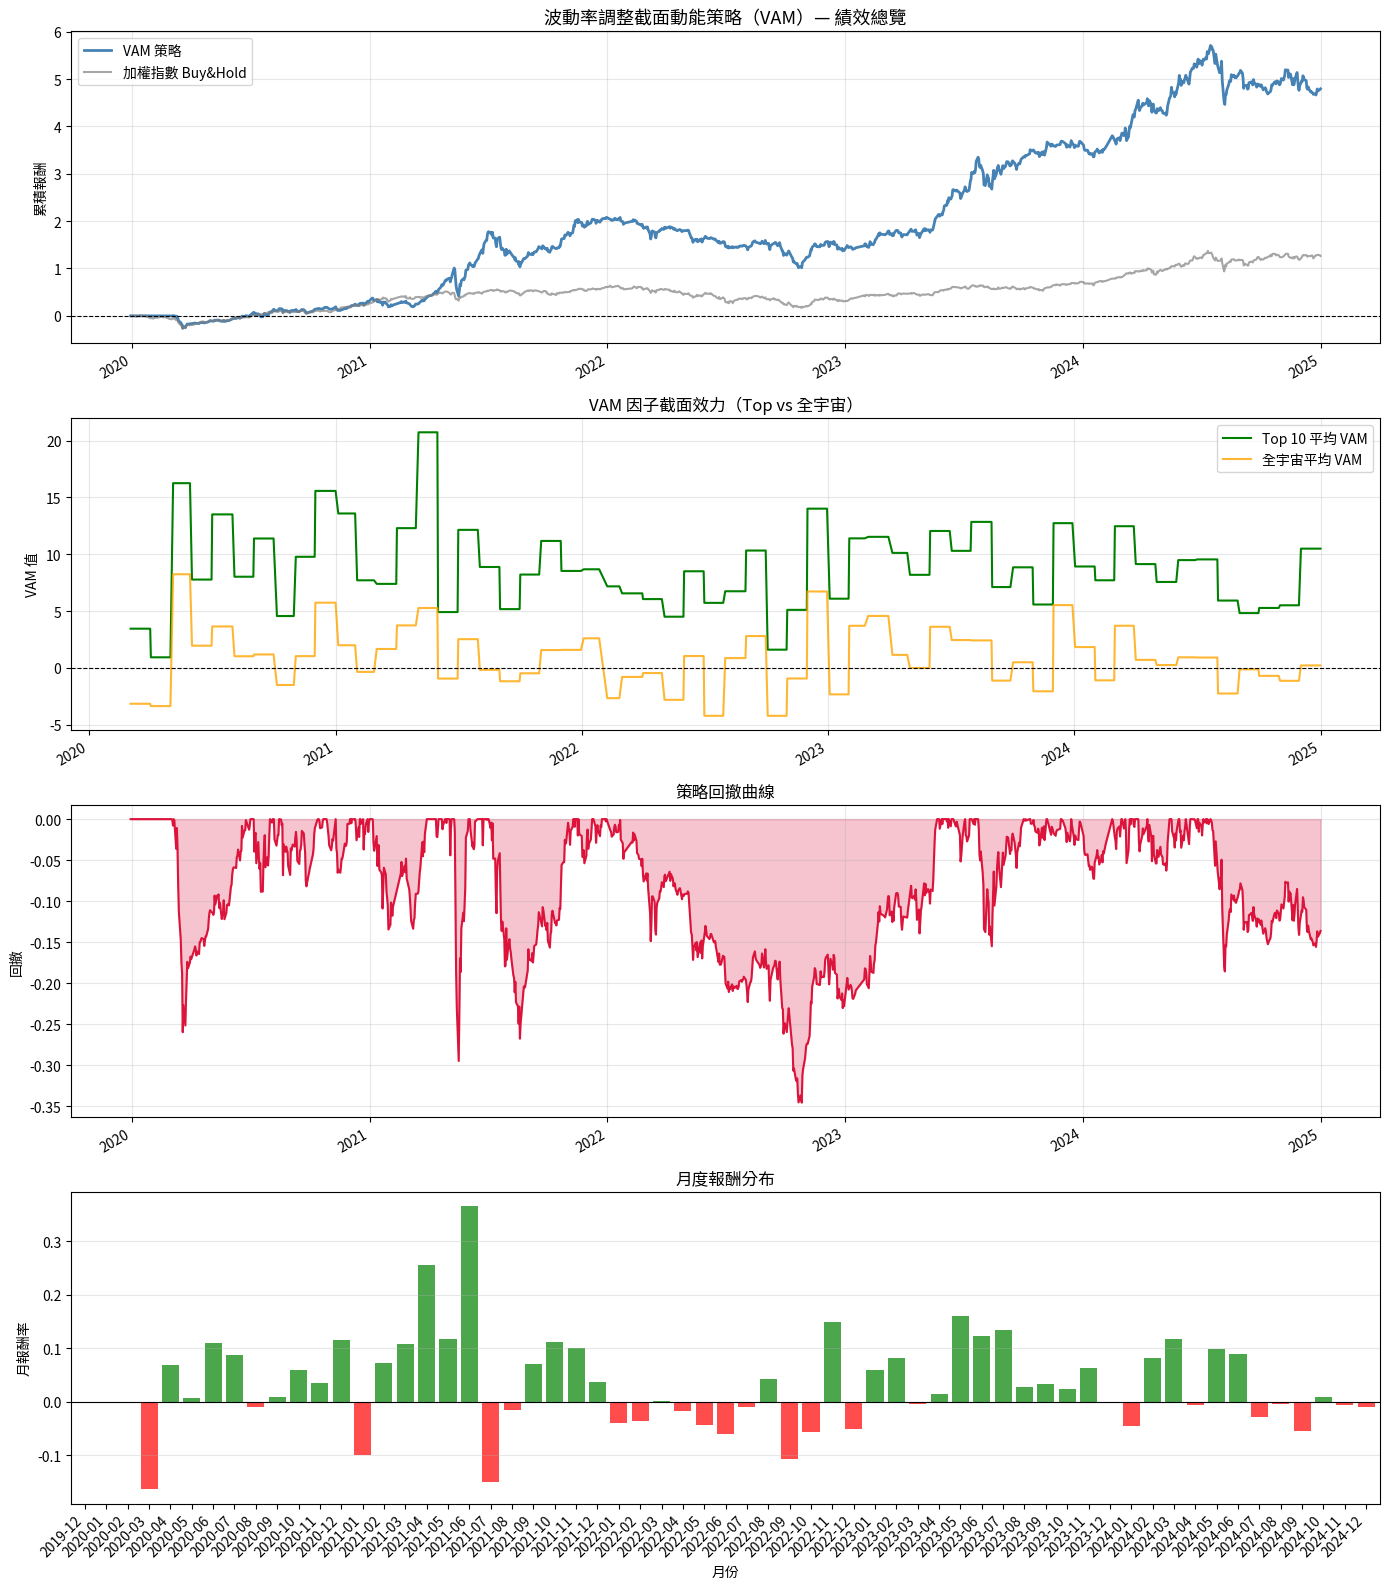


  波動率調整截面動能策略（VAM）— 績效摘要
  回測期間      : 2019-12-30 ~ 2024-12-31
  初始資金      :    1,000,000 元
  最終資金      :    5,794,607 元
  總報酬率      : +479.46%
  年化報酬      : +43.84%
  最大回撤      : -34.55%
  夏普比率      : 1.401
  月度勝率      : 57.4%
  績效資料已存至 vam_perf_result.csv

回測完成！


In [7]:
from zipline import run_algorithm

print('=' * 60)
print('  開始回測：波動率調整截面動能策略（VAM）')
print(f'  期間：{start_date} ~ {end_date}')
print(f'  流動性前 {LIQUIDITY_TOP_N} → 做多前 {TOP_N} 名，等權重')
print('=' * 60)

results = run_algorithm(
    start                = pd.Timestamp(start_date, tz='utc'),
    end                  = pd.Timestamp(end_date,   tz='utc'),
    initialize           = initialize,
    before_trading_start = before_trading_start,
    handle_data          = handle_data,
    analyze              = analyze,
    bundle               = 'tquant',
    capital_base         = capital_base,
    data_frequency       = 'daily'
)

print('\n回測完成！')

In [8]:
# ── 每月選股紀錄 ─────────────────────────────────────────────────────
picks = pd.DataFrame([
    {'date': date, 'stocks': ', '.join(sorted(stocks))}
    for date, stocks in sorted(_picks_log.items())
])
picks.to_csv('vam_picks.csv', index=False)

print('=== 每月選股紀錄 ===')
print(picks.to_string(index=False))
print(f'\n已儲存至 vam_picks.csv')

=== 每月選股紀錄 ===
      date                                                     stocks
2020-03-02 1707, 1904, 2201, 2801, 3189, 3532, 3706, 6531, 8046, 9958
2020-04-01 2345, 2347, 2356, 2368, 2458, 2915, 5269, 6669, 8046, 9958
2020-05-04 1722, 2049, 2301, 2337, 2448, 3017, 3037, 3661, 6531, 6592
2020-06-01 1722, 2108, 2347, 2404, 3533, 5269, 6278, 6415, 9914, 9921
2020-07-01 2458, 3189, 3231, 3406, 3661, 5264, 6176, 6531, 8046, 8454
2020-08-03 2376, 2377, 2379, 2448, 2458, 3023, 3034, 3037, 8046, 9914
2020-09-01 1605, 1904, 2108, 2231, 2603, 3017, 3665, 6285, 9945, 9958
2020-10-05 1519, 1904, 2006, 2344, 2408, 2542, 3034, 3533, 3682, 5264
2020-11-02 1605, 2108, 2344, 2371, 2492, 2603, 2609, 3576, 6472, 9914
2020-12-01 1802, 2049, 2105, 2352, 2408, 2449, 2615, 3037, 6531, 8046
2021-01-04 1314, 2014, 2049, 2324, 2345, 2352, 2603, 2609, 3034, 4961
2021-02-01 2354, 2441, 2458, 3661, 3665, 5269, 6531, 8046, 8454, 8464
2021-03-02 2301, 2337, 2352, 2409, 2609, 2610, 2618, 3481, 8046, 8454
2021-

## 📌 Pyfolio 完整報告

若已安裝 `pyfolio`，可執行此 Cell 產生完整的 tear sheet，  
包含月度報酬熱力圖、滾動 Sharpe、持倉集中度分析等。

------ 大盤績效 ------


Start date,2019-12-30
End date,2024-12-31
Total months,58
,Backtest
Annual return,18.425%
Cumulative returns,126.456%
Annual volatility,18.617%
Sharpe ratio,1.00
Calmar ratio,0.65
Stability,0.76
Max drawdown,-28.553%


------ VAM 策略完整報告 ------


Start date,2019-12-30
End date,2024-12-31
Total months,58
,Backtest
Annual return,43.836%
Cumulative returns,479.461%
Annual volatility,28.966%
Sharpe ratio,1.40
Calmar ratio,1.27
Stability,0.91
Max drawdown,-34.552%


Worst drawdown periods,Net drawdown in %,Peak date,Valley date,Recovery date,Duration
0,34.55,2021-12-30,2022-10-26,2023-05-22,333
1,29.48,2021-05-10,2021-05-17,2021-06-01,17
2,26.76,2021-07-02,2021-08-19,2021-11-09,90
3,25.97,2020-03-05,2020-03-19,2020-07-01,80
4,18.56,2024-07-15,2024-08-06,NaT,NaN


Top 10 long positions of all time,max
sid,
2609,17.27%
2615,15.78%
1503,15.22%
2603,14.77%
3231,14.35%
3035,14.27%
2108,13.97%
6531,13.55%
3037,13.55%


Top 10 short positions of all time,max
sid,


Top 10 positions of all time,max
sid,
2609,17.27%
2615,15.78%
1503,15.22%
2603,14.77%
3231,14.35%
3035,14.27%
2108,13.97%
6531,13.55%
3037,13.55%


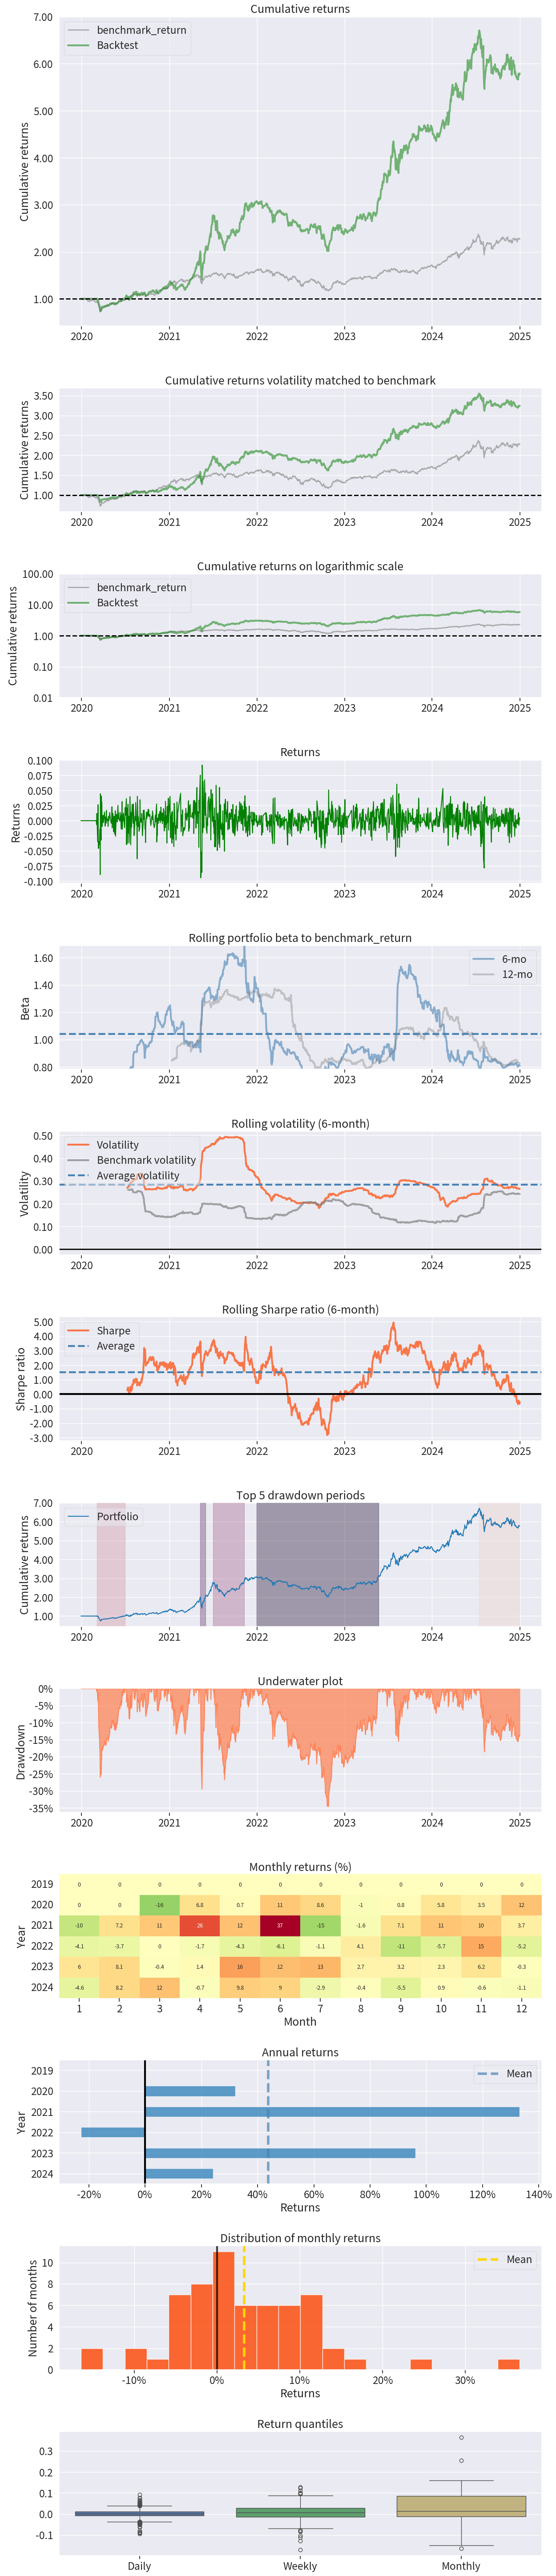

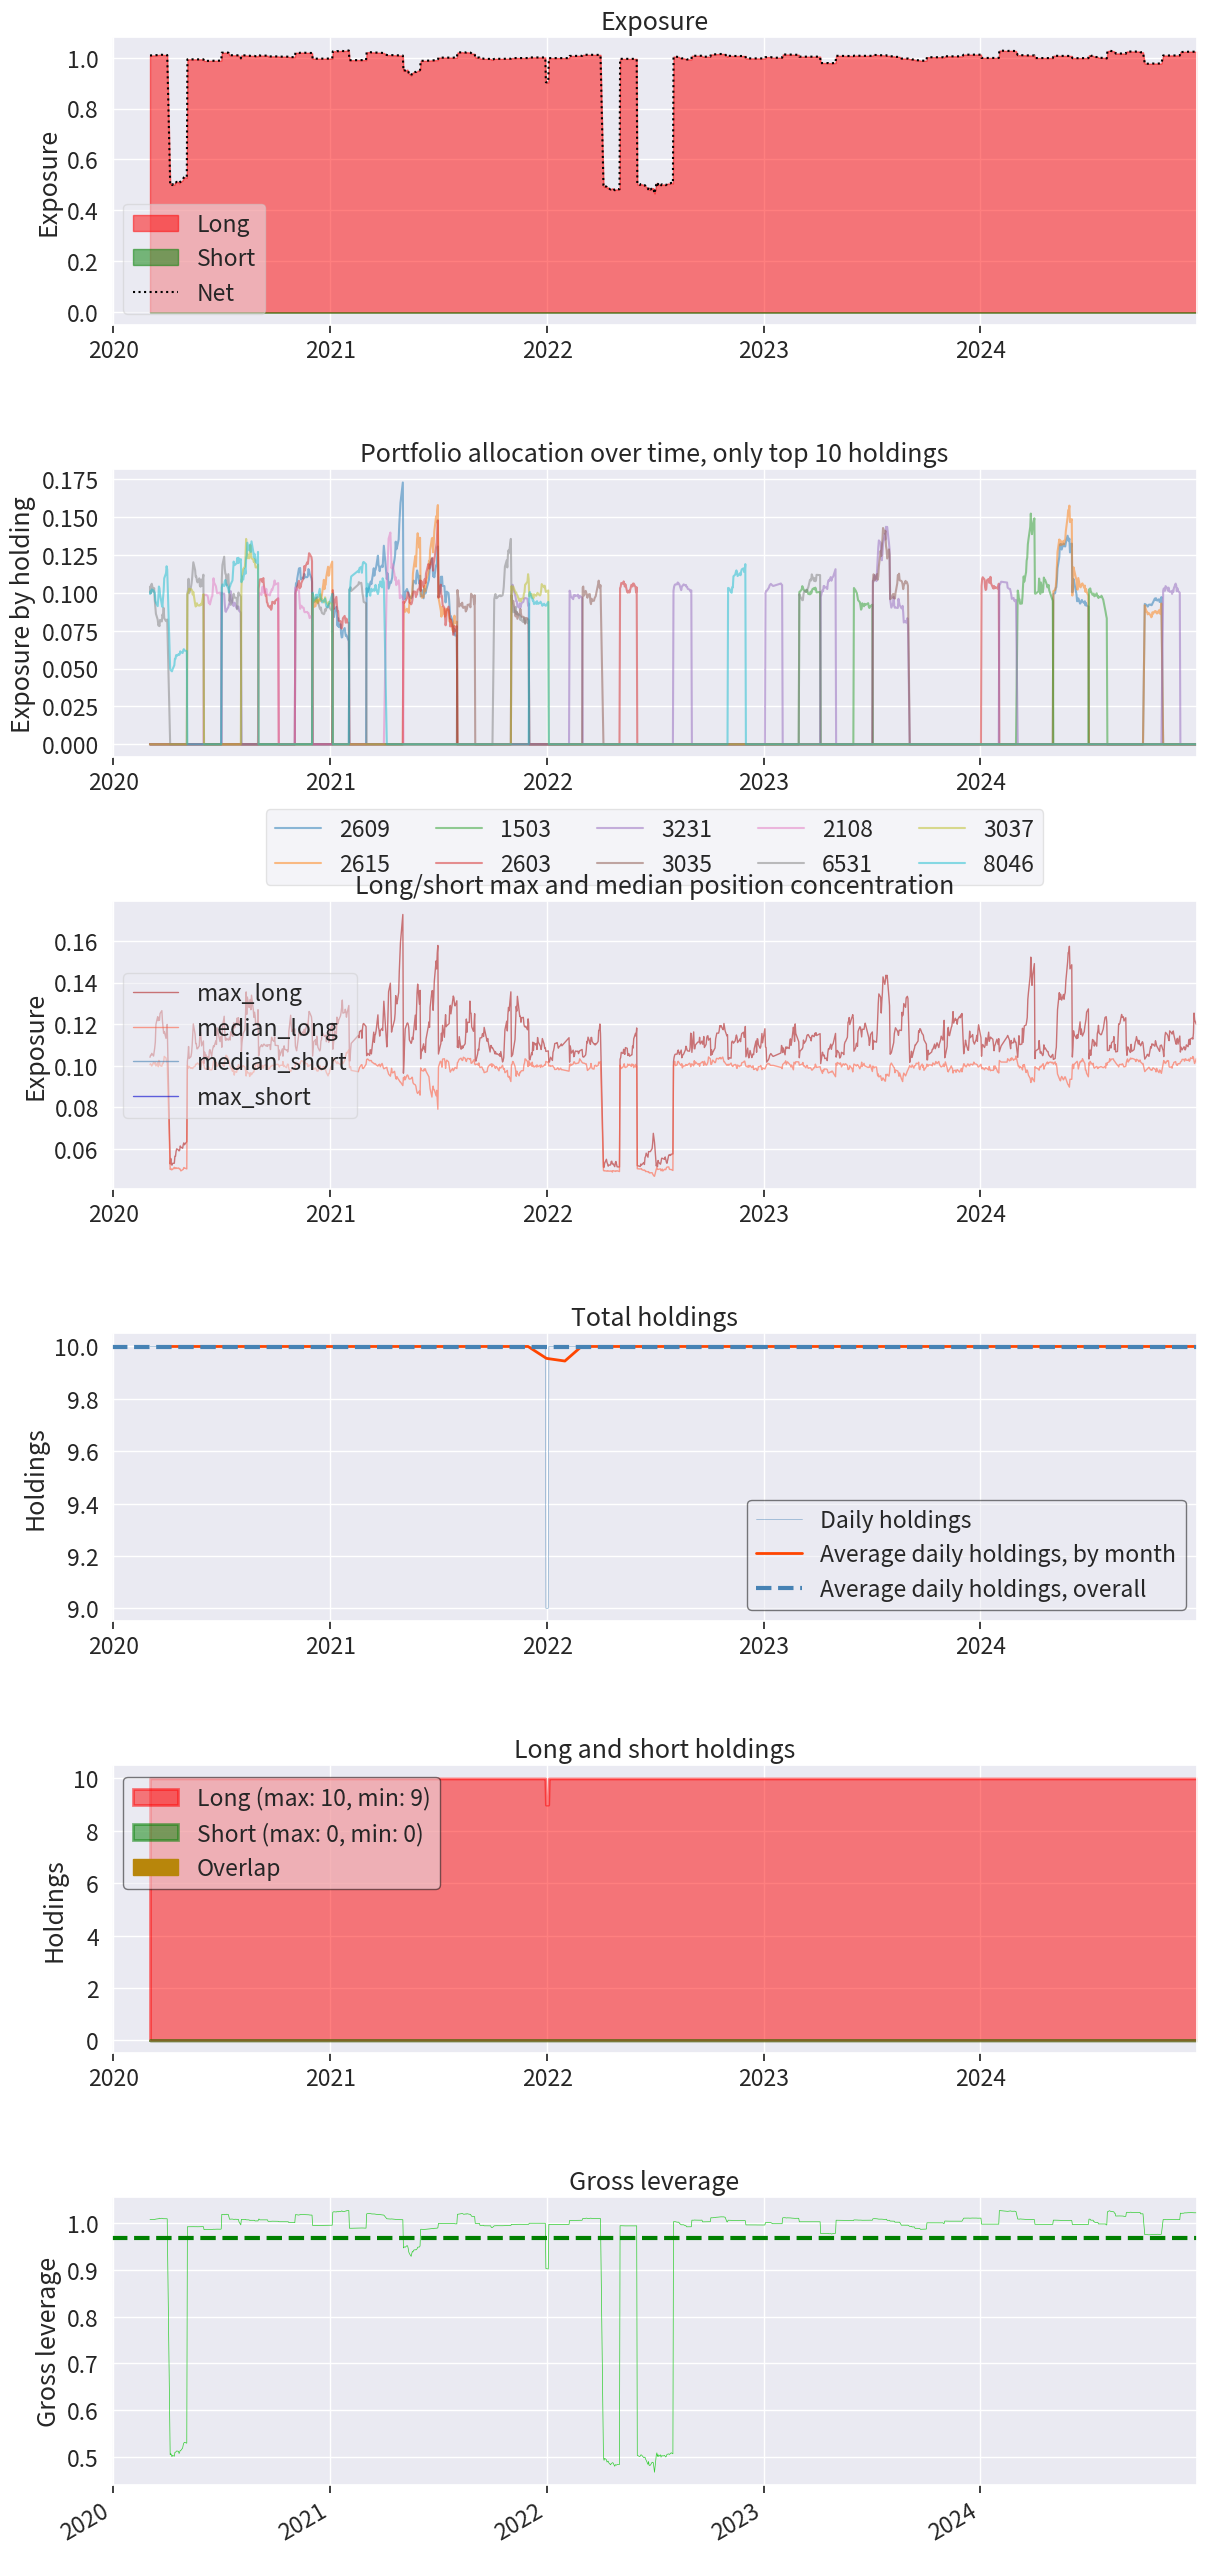

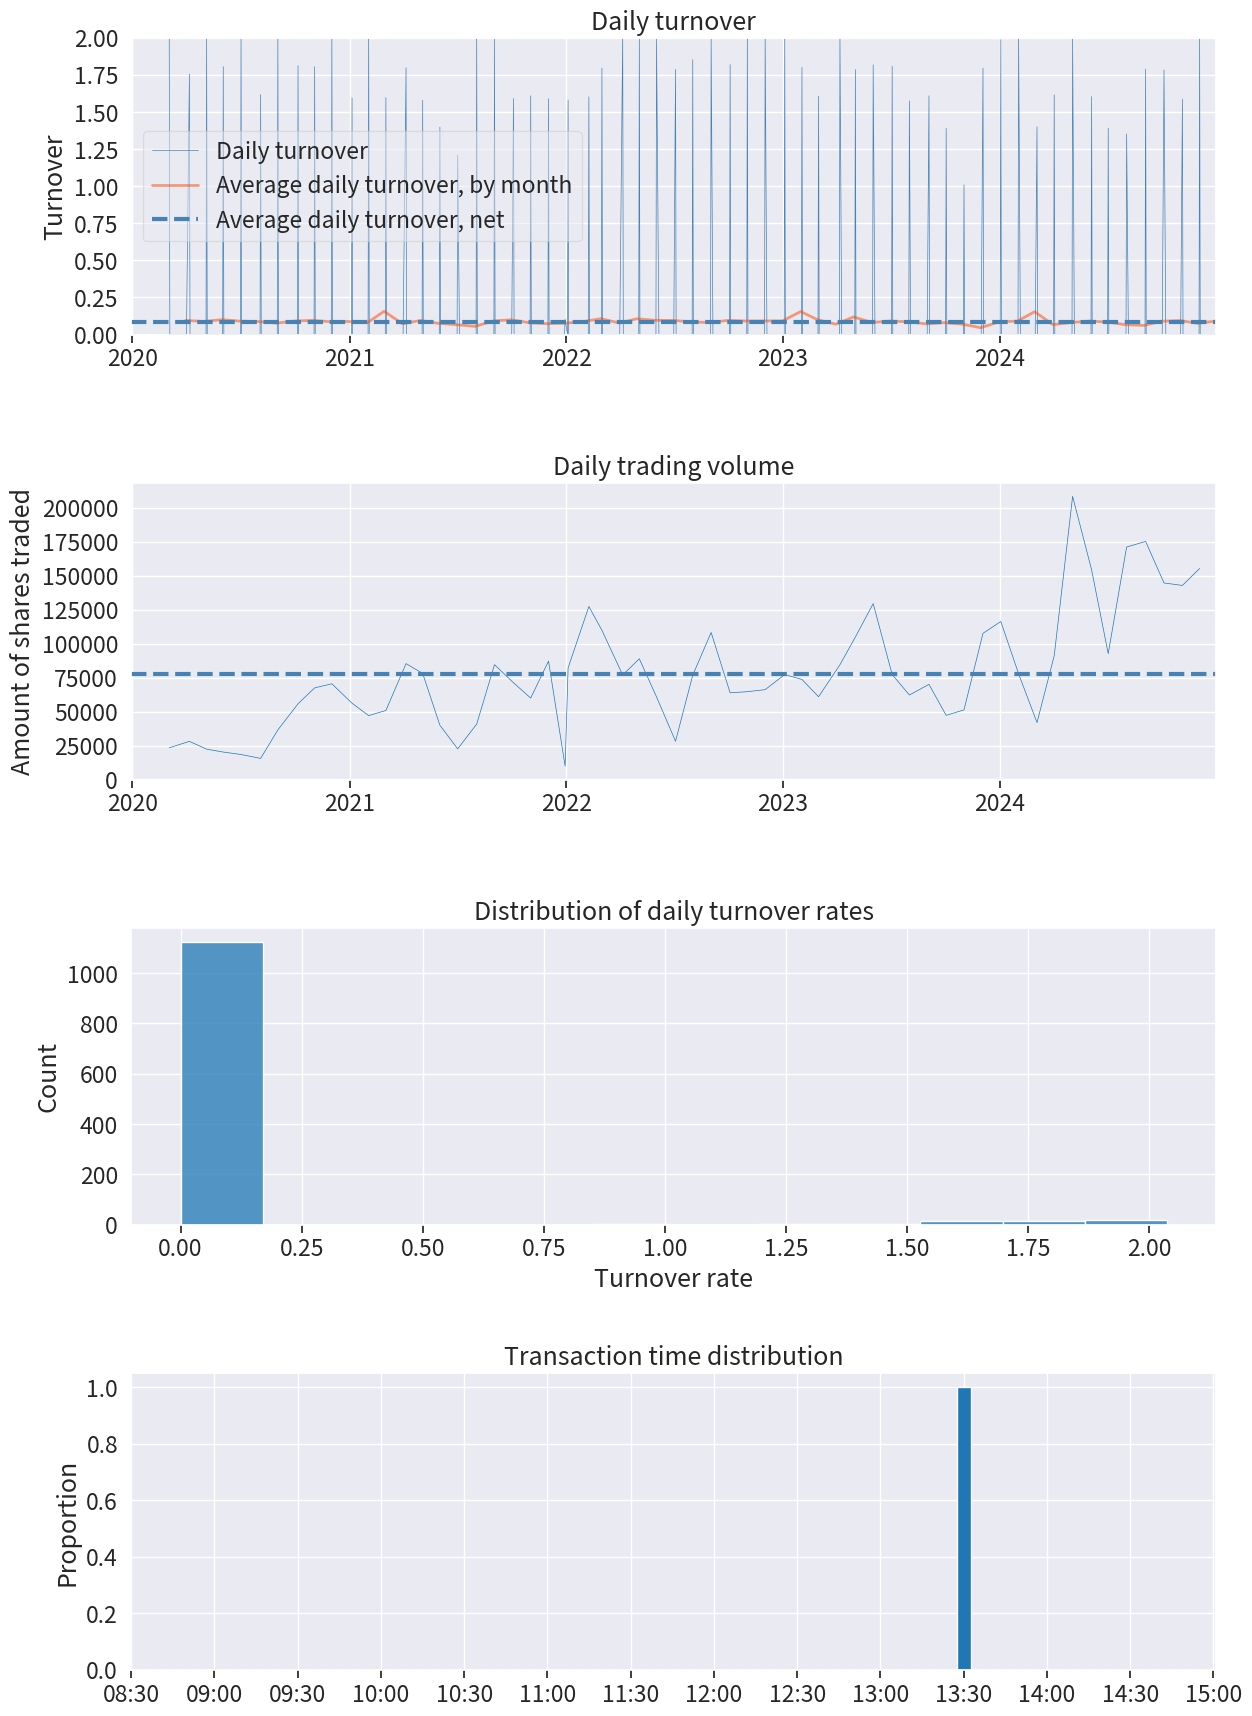

In [9]:
try:
    import logging
    import pyfolio as pf
    import matplotlib.pyplot as plt

    logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)

    plt.rcParams['font.sans-serif'] = ['Source Han Sans TC', 'DejaVu Sans']
    plt.rcParams['axes.unicode_minus'] = False

    from pyfolio.utils import extract_rets_pos_txn_from_zipline

    returns, positions, transactions = extract_rets_pos_txn_from_zipline(results)
    benchmark_rets = results.benchmark_return

    print('------ 大盤績效 ------')
    pf.show_perf_stats(benchmark_rets)

    print('------ VAM 策略完整報告 ------')
    pf.tears.create_full_tear_sheet(
        returns        = returns,
        positions      = positions,
        transactions   = transactions,
        benchmark_rets = benchmark_rets
    )
except ImportError:
    print('未安裝 pyfolio，略過。如需安裝：pip install pyfolio')
except Exception as e:
    print(f'Pyfolio 分析錯誤: {e}')